# **Fase 3: Modelos de Regresion**

Estudiante: Maria Camila Navarrete Pinzón

Código: 2294353

Fecha: 07 febrero, 2026

# Notebook 5: Regresion lineal

**Objetivo**: Entrenar un modelo de regresión lineal para predecir el precio base.

**Actividades**:
- Dividir datos en train/test
- Entrenar LinearRegression
- Evaluar con RMSE, MAE, R²
- Analizar coeficientes

## 1. Configuración de SparkSession

Se crea una sesión de spark configurada para ejecutarse en modo local, asignando memoria al driver.

In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col

# %%
spark = SparkSession.builder \
    .appName("SECOP_RegresionLineal") \
    .master("local[*]") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/13 02:40:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/13 02:41:06 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


## 2. Carga de datos

In [2]:
df = spark.read.parquet("/opt/spark-data/processed/secop_ml_ready.parquet")
df = df.withColumnRenamed("valor_del_contrato_num", "label") \
       .withColumnRenamed("features_pca", "features")
df = df.filter(col("label").isNotNull())
print(f"Registros: {df.count():,}")
print(f"Columnas: {len(df.columns)}")

Registros: 52,248
Columnas: 2


## 3. Reto 1 - Train/Test Split Strategy

**Pregunta**: ¿Qué proporción usarías para train vs test?

**Opciones**:
- A) 50/50 - Máxima validación
- B) 70/30 - Balance clásico
- C) 80/20 - Más datos para entrenar
- D) 90/10 - Máximo entrenamiento

**Consideración**: ¿Qué pasa si tienes 1 millón de registros vs 1000?

**Justifica tu decisión**

B.) Esta permite entrenar el modelo con una cantidad suficiente de datos para aprender patrones, sin sacrificar una porción representativa para evaluar su desempeño en datos no vistos. Dado que el conjunto de datos es amplio, esta proporción ofrece un buen equilibrio entre capacidad de aprendizaje y evaluación confiable del modelo, reduciendo el riesgo de sobreajuste y asegurando resultados reproducibles.


### 3.1 Definir estrategia de train/test split

In [4]:
train_ratio = 0.7
test_ratio = 0.3

train, test = df.randomSplit([train_ratio, test_ratio], seed=42)

print(f"Train: {train.count():,} registros (70%)")
print(f"Test: {test.count():,} registros (30%)")


Train: 36,729 registros (70%)


Test: 15,519 registros (30%)


**Pregunta** ¿Por qué es importante usar seed=42?: 

Usar una semilla garantiza la reproducinilidad en el proceso, con el fin de ver el mismo resultado si se vuelve a ejecutar el código. 


## 4. Reto 2 - Configurar el Modelo

**Objetivo**: Configurar LinearRegression con los parámetros correctos

**Parámetros clave**:
- featuresCol: Columna de features
- labelCol: Columna objetivo
- maxIter: Iteraciones máximas (¿10, 100, 1000?)
- regParam: Regularización (0.0 = sin regularización)
- elasticNetParam: Tipo de regularización (0=L2, 1=L1)

In [5]:
lr = LinearRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)

print("✓ Modelo configurado")
print(f"maxIter: {lr.getMaxIter()}")
print(f"regParam: {lr.getRegParam()}")


✓ Modelo configurado
maxIter: 100
regParam: 0.0


In [6]:
print("Entrenando modelo...")
lr_model = lr.fit(train)

print("✓ Modelo entrenado")
print(f"Iteraciones: {lr_model.summary.totalIterations}")
print(f"RMSE (train): ${lr_model.summary.rootMeanSquaredError:,.2f}")
print(f"R² (train): {lr_model.summary.r2:.4f}")


Entrenando modelo...


26/02/13 03:16:11 WARN Instrumentation: [704f3db9] regParam is zero, which might cause numerical instability and overfitting.
26/02/13 03:16:12 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/02/13 03:16:12 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/02/13 03:16:13 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


✓ Modelo entrenado
Iteraciones: 0
RMSE (train): $23,984,177,356.11
R² (train): 0.0287


El modelo fue entrenado correctamente, pero los resultados indican un desempeño bajo. El hecho de que el número de iteraciones sea 0 sugiere que el modelo prácticamente no aprendió patrones relevantes de los datos, lo que se refleja en un R² de 0.0287, indicando que solo explica cerca del 2.9 % de la variabilidad de la variable objetivo. Además, el RMSE extremadamente alto evidencia grandes errores de predicción y coherentes con la alta dispersión.

## 5. Reto 3 - Interpretar R²

**Pregunta**: Si R² = 0.65, ¿qué significa?

**Opciones**:

- A) El modelo es 65% preciso
- B) El modelo explica 65% de la varianza en los datos
- C) El modelo tiene 65% de error
- D) El modelo está 35% equivocado

**Respuesta:** B.) El modelo explica el 65% de la varianza en los datos.

**R² significa:** Indica cuánta variabilidad del valor del contrato puede explicar el modelo.

**¿Es 0.65 un buen R²?. Depende de:** Depende del dominio.

### 5.1 Predicciones en Test

In [7]:
predictions = lr_model.transform(test)

predictions.select("label", "prediction").show(10)


+---------+--------------------+
|    label|          prediction|
+---------+--------------------+
|1950000.0|-2.13256329795050...|
|1950000.0|-2.13256329795050...|
|1950000.0|-2.13256329795050...|
|1950000.0|-2.13256329795050...|
|1950000.0|-2.13256329795050...|
|1950000.0|-2.13256329795050...|
|1950000.0|-2.13256329795050...|
|2050000.0|-2.13256095561159...|
|2050000.0|-2.13256095561159...|
|2050000.0|-2.13256095561159...|
+---------+--------------------+
only showing top 10 rows



## 6. Reto 4 - Análisis de predicciones y errores

**Objetivo**: Analizar la calidad de las predicciones

**Instrucciones**:
- Calcula el error absoluto por cada predicción
- Identifica las 10 predicciones con mayor error
- ¿Hay un patrón en los errores grandes?

In [12]:
from pyspark.sql.functions import abs as spark_abs

predictions_with_error = predictions.withColumn(
    "absolute_error",
    spark_abs(col("prediction") - col("label"))
)

predictions_with_error \
    .orderBy(col("absolute_error").desc()) \
    .select("label", "prediction", "absolute_error") \
    .show(10)
predictions_with_error = predictions_with_error.withColumn(
    "error_pct",
    (col("absolute_error") / col("label")) * 100
)


+----------------+--------------------+--------------------+
|           label|          prediction|      absolute_error|
+----------------+--------------------+--------------------+
| 3.2270974689E11|1.977322230674265...|3.029365245832573E11|
|1.59204916906E11|1.272803777875763...|1.464768791272423...|
|1.59204916906E11|1.272803777875763...|1.464768791272423...|
|1.59204916906E11|1.272803777875763...|1.464768791272423...|
|1.49095646497E11|1.249124440489486...|1.366044020921051...|
|1.44973755369E11|1.064213882293208...|1.343316165460679...|
|1.19159055827E11| 7.080425376208071E9|1.120786304507919...|
| 1.0273185156E11|3.3902441389009585E9|9.934160742109904E10|
|1.04855613958E11|1.291778327118412...|9.193783068681587E10|
| 6.5334947932E10|2.2976811420732756E9|6.303726678992673E10|
+----------------+--------------------+--------------------+
only showing top 10 rows



El análisis de las predicciones muestra que el modelo presenta errores absolutos muy elevados, especialmente en contratos de alto valor, donde las predicciones quedan muy por debajo de los valores reales. En varios casos, el error es del mismo orden de magnitud que el valor del contrato, lo que indica que el modelo no está capturando adecuadamente la escala ni la variabilidad de los datos. Este patrón sugiere dificultades para modelar correctamente los valores extremos y refuerza la idea de que el modelo tiene una capacidad predictiva limitada.

### 6.1 TOP 10 peores predicciones

In [10]:
from pyspark.sql.functions import abs as spark_abs, col
print("\nTOP 10 Peores predicciones")
predictions_with_error \
    .orderBy(col("absolute_error").desc()) \
    .select("label", "prediction", "absolute_error") \
    .show(10, truncate=False)
predictions_with_error = predictions_with_error.withColumn(
    "error_porcentual",
    (col("absolute_error") / col("label")) * 100
)
print("\nContratos con error > 100%")
predictions_with_error \
    .filter(col("error_porcentual") > 100) \
    .select("label", "prediction", "absolute_error", "error_porcentual") \
    .orderBy(col("error_porcentual").desc()) \
    .show(10, truncate=False)


TOP 10 Peores predicciones


+----------------+---------------------+---------------------+
|label           |prediction           |absolute_error       |
+----------------+---------------------+---------------------+
|3.2270974689E11 |1.9773222306742657E10|3.029365245832573E11 |
|1.59204916906E11|1.2728037778757637E10|1.4647687912724237E11|
|1.59204916906E11|1.2728037778757637E10|1.4647687912724237E11|
|1.59204916906E11|1.2728037778757637E10|1.4647687912724237E11|
|1.49095646497E11|1.2491244404894867E10|1.3660440209210513E11|
|1.44973755369E11|1.0642138822932081E10|1.3433161654606792E11|
|1.19159055827E11|7.080425376208071E9  |1.1207863045079193E11|
|1.0273185156E11 |3.3902441389009585E9 |9.934160742109904E10 |
|1.04855613958E11|1.2917783271184126E10|9.193783068681587E10 |
|6.5334947932E10 |2.2976811420732756E9 |6.303726678992673E10 |
+----------------+---------------------+---------------------+
only showing top 10 rows


Contratos con error > 100%


+---------+----------------------+---------------------+---------------------+
|label    |prediction            |absolute_error       |error_porcentual     |
+---------+----------------------+---------------------+---------------------+
|1.0      |8.86237931520974E9    |8.86237931420974E9   |8.86237931420974E11  |
|1.0      |-1.4091531390594754E9 |1.4091531400594754E9 |1.4091531400594754E11|
|1.0      |-1.4091531390594754E9 |1.4091531400594754E9 |1.4091531400594754E11|
|1.0      |-8.736219809402981E8  |8.736219819402981E8  |8.736219819402982E10 |
|4.0      |9.839160114569216E8   |9.839160074569216E8  |2.459790018642304E10 |
|1000.0   |-3.0195975700456924E9 |3.0195985700456924E9 |3.0195985700456923E8 |
|1066042.0|-1.9917180067153046E10|1.9918246109153046E10|1868429.7719182777   |
|600000.0 |1.099136654555697E10  |1.099076654555697E10 |1831794.4242594952   |
|83000.0  |1.3214365715060842E9  |1.3213535715060842E9 |1591992.2548266074   |
|455200.0 |7.207533743376307E9   |7.207078543376307E

Estos resultados muestran que las peores predicciones del modelo se concentran en contratos de valores muy altos, donde el modelo subestima fuertemente el precio real. En todos los casos, las predicciones están en el orden de miles de millones, mientras que los valores reales alcanzan decenas o cientos de miles de millones, lo que genera errores absolutos extremadamente grandes.

### 6.2 Evaluación formal

In [11]:
evaluator_rmse = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="rmse"
)

evaluator_mae = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="mae"
)

evaluator_r2 = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="r2"
)

rmse = evaluator_rmse.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

print("Métricas")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE:  ${mae:,.2f}")
print(f"R²:   {r2:.4f}")


Métricas
RMSE: $5,743,644,041.38
MAE:  $2,986,509,244.41
R²:   -0.5405


## 7. Reto 5 - Comparar Train vs Test

**Objetivo**: Detectar overfitting o underfitting

**Pregunta**: ¿Qué indica cada escenario?

- A) R² train = 0.9, R² test = 0.85 → ¿Qué pasa?: Este escenario indica un modelo bien generalizado. El desempeño en test es muy similar al de train, lo que significa que el modelo aprendió patrones reales de los datos y los reproduce correctamente en datos no vistos.
  
- B) R² train = 0.6, R² test = 0.58 → ¿Qué pasa?: Aquí el modelo muestra underfitting. Ambos R² son bajos y muy cercanos entre sí, lo que indica que el modelo es consistente pero demasiado simple para capturar la relación real entre las variables y el objetivo.

- C) R² train = 0.95, R² test = 0.45 → ¿Qué pasa?: Este caso representa un overfitting claro. El modelo se ajusta extremadamente bien a los datos de entrenamiento, pero falla al generalizar en test. Esto suele ocurrir cuando el modelo es demasiado complejo, hay ruido en los datos o no se aplica regularización.

**Compara tus resultados**

In [14]:
print("\nComparación TRAIN VS TEST")
print(f"R² Train:  {lr_model.summary.r2:.4f}")
print(f"R² Test:   {r2:.4f}")
print(f"Diferencia: {abs(lr_model.summary.r2 - r2):.4f}")


Comparación TRAIN VS TEST
R² Train:  0.0287
R² Test:   -0.5405
Diferencia: 0.5693


- ¿Hay overfitting? **No**
- ¿Hay underfitting? **Si**
- Justifica: El R² en train es muy bajo, lo que indica que el modelo casi no explica la variabilidad del valor del contrato ni siquiera en los datos con los que fue entrenado. Esto descarta el overfitting, ya que el modelo no está ajustándose bien ni al conjunto de entrenamiento. Además, el R² negativo en test indica que el modelo generaliza peor que una predicción trivial basada en el promedio del target, lo cual es una señal clara de que el modelo es demasiado simple o inadecuado para capturar la relación entre las variables.

## 8. Reto 6 - Analizar Coeficientes

**Objetivo**: Entender qué features son más importantes

**Pregunta**: Si un coeficiente es muy grande (positivo o negativo), ¿qué significa?

Si un coeficiente es muy grande (positivo o negativo), significa que esa feature tiene una influencia fuerte en la predicción del modelo. Un coeficiente positivo grande indica que, cuando esa variable aumenta, la predicción del valor del contrato tiende a incrementarse significativamente, mientras que un coeficiente negativo grande indica que su aumento hace que la predicción disminuya de forma importante.

In [15]:
import numpy as np

coef_array = np.array(lr_model.coefficients)
abs_coefs = np.abs(coef_array)
top_5_idx = np.argsort(abs_coefs)[-5:]

print("TOP 5 Coeficientes mas influyentes")
for i, idx in enumerate(reversed(top_5_idx)):
    print(f"{i+1}. Feature {idx}: coef = {coef_array[idx]:.4f}")


TOP 5 Coeficientes mas influyentes
1. Feature 2: coef = 2204258793.7523
2. Feature 7: coef = 2083095543.8750
3. Feature 4: coef = -1532100487.8470
4. Feature 8: coef = -753864947.9084
5. Feature 5: coef = 673063525.3124


**Pregunta**: ¿Qué significa un coeficiente positivo vs negativo?

Las features 2 y 7, con coeficientes positivos muy altos, tienen un impacto directo y dominante en el aumento de la predicción del valor del contrato, cuando estas variables crecen, el valor estimado aumenta de forma considerable. En contraste, las features 4 y 8 presentan coeficientes negativos grandes, lo que significa que su incremento reduce significativamente la predicción. La feature 5, aunque con menor magnitud relativa, sigue teniendo una influencia relevante. En conjunto, esto sugiere que el modelo depende de pocas variables clave y que su comportamiento puede ser sensible a cambios en estas features

## 9. Bonus 1 - Analisis de distribucion de residuos

**Objetivo**: Analizar la distribución de los errores (residuos)

**Pregunta**: En un buen modelo, ¿cómo deberían distribuirse los residuos?

**Instrucciones**:
- Calcula residuo = label - prediction
- Genera un histograma de residuos
- ¿Están centrados en cero?
- ¿Hay sesgo (bias)?


Text(0, 0.5, 'Frecuencia')

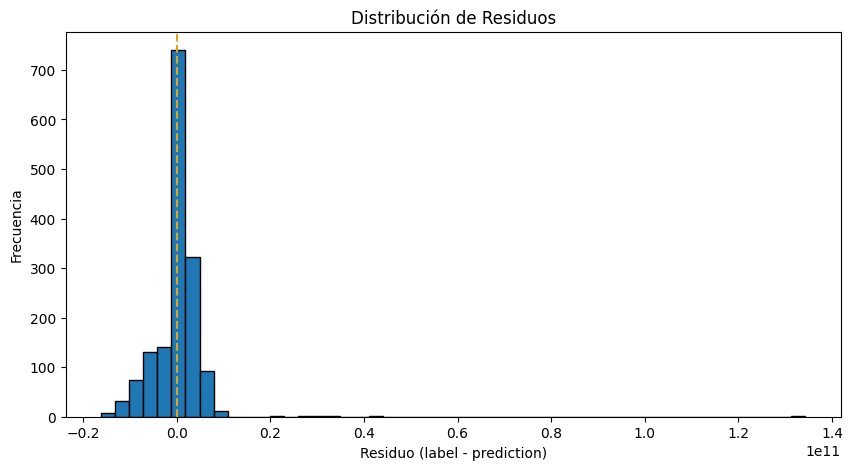

In [18]:
import matplotlib.pyplot as plt

residuals_df = predictions.withColumn(
    "residual", col("label") - col("prediction")
)

residuals_sample = residuals_df.select("residual").sample(0.1).toPandas()

plt.figure(figsize=(10,5))
plt.hist(residuals_sample["residual"], bins=50, edgecolor="black")
plt.axvline(0, color="goldenrod", linestyle="--")
plt.title("Distribución de Residuos")
plt.xlabel('Residuo (label - prediction)')
plt.ylabel('Frecuencia')



La distribución de los residuos está centrada cerca de cero esto indica que en promedio el modelo no tiene un sesgo fuerte. Sin embargo, se observa una asimetría marcada hacia la derecha con outliers muy grandes, lo que sugiere que el modelo falla gravemente en algunos contratos de alto valor, produciendo errores extremos. .

## 10. Preguntas de reflexion

**¿Por qué usar RMSE en lugar de solo MAE?**

*Respuesta:* El RMSE penaliza más los errores grandes porque eleva el error al cuadrado antes de promediarlo, mientras que el MAE trata todos los errores por igual. Usar RMSE ayuda a detectar modelos que se equivocan poco pero fallan gravemente en casos extremos.

**Si todas las predicciones fueran = promedio de labels, ¿cuál sería el R²?**

*Respuesta:* Sería 0 ya que se debe a que el modelo no explica ninguna variabilidad adicional más allá de la media; es el baseline más simple posible. Un R² negativo indica que el modelo es incluso peor que predecir siempre el promedio.

**¿Cuándo preferirías optimizar para RMSE vs MAE?**

*Respuesta:* 

- RMSE: cuando los errores grandes son críticos.
- MAE: cuando es necesaria una métrica más robusta a outliers y una interpretación más directa del error promedio esperado.

**¿Cómo mejorarías este modelo? (menciona al menos 3 estrategias)**


*Respuesta:*

- Transformar la variable objetivo para manejar la alta dispersión y los valores extremos.
- Probar modelos no lineales como Random Forest, que capturan mejor relaciones complejas.
- Mejorar el feature engineering: nuevas variables, interacciones o segmentar por tipo de contrato.

In [19]:

model_path = "/opt/spark-data/processed/linear_regression_model"
lr_model.write().overwrite().save(model_path)
print(f"\n✓ Modelo guardado en: {model_path}")

predictions_path = "/opt/spark-data/processed/predictions_lr.parquet"
predictions.write.mode("overwrite").parquet(predictions_path)
print(f"✓ Predicciones guardadas en: {predictions_path}")

print("Resumen regresion linealL")
print(f"✓ Modelo entrenado con {train.count():,} registros")
print(f"✓ Evaluado con {test.count():,} registros")
print(f"✓ RMSE: ${rmse:,.2f}")
print(f"✓ R²: {r2:.4f}")
print(f"✓ Próximo paso: Probar regularización (notebook 07)")


✓ Modelo guardado en: /opt/spark-data/processed/linear_regression_model


✓ Predicciones guardadas en: /opt/spark-data/processed/predictions_lr.parquet
Resumen regresion linealL


✓ Modelo entrenado con 36,729 registros


✓ Evaluado con 15,519 registros
✓ RMSE: $5,743,644,041.38
✓ R²: -0.5405
✓ Próximo paso: Probar regularización (notebook 07)


In [20]:
spark.stop()